# Tienda online Ice

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

**Plan de acción - Proyecto Ice (Videojuegos)**

**Paso 1: Abrir y estudiar información general**

    1.1 Cargar datos y librerías
    1.2 Cargar dataset
    1.3 Exploración inicial

**Paso 2: Preparar los datos**

    2.1 Reemplazar nombres de columnas (minúsculas)
    2.2 Convertir tipos de datos necesarios
    2.3 Analizar valores ausentes
    2.4 Manejar casos TBD (To Be Determined)
    2.5 Calcular ventas totales

**Paso 3: Analizar los datos**

    3.1 Juegos lanzados por año
    3.2 Ventas por plataforma
    3.3 Ciclo de vida de plataformas (tu ejercicio actual)
    3.4 Período relevante para análisis (2014-2016)

**Paso 4: Crear perfil de usuario por región**

    4.1 Top 5 plataformas por región
    4.2 Top 5 géneros por región
    4.3 Impacto del rating ESRB por región

**Paso 5: Probar hipótesis**

    5.1 Hipótesis 1: Calificaciones promedio Xbox One vs PC
    5.2 Hipótesis 2: Calificaciones promedio Action vs Sports

**Paso 6: conclusión general**

## Paso 1. Abre el archivo de datos y estudia la información general

### Importar librerías

In [449]:
# Importar las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

### Estudíando el datasest

In [450]:
# Leer el dataset
games_df = pd.read_csv('datasets/games.csv')

In [451]:
# Ver información general
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [452]:
# Ver una muestra de los datos del DataFrame
print(games_df.head(20))

                                            Name Platform  Year_of_Release  \
0                                     Wii Sports      Wii           2006.0   
1                              Super Mario Bros.      NES           1985.0   
2                                 Mario Kart Wii      Wii           2008.0   
3                              Wii Sports Resort      Wii           2009.0   
4                       Pokemon Red/Pokemon Blue       GB           1996.0   
5                                         Tetris       GB           1989.0   
6                          New Super Mario Bros.       DS           2006.0   
7                                       Wii Play      Wii           2006.0   
8                      New Super Mario Bros. Wii      Wii           2009.0   
9                                      Duck Hunt      NES           1984.0   
10                                    Nintendogs       DS           2005.0   
11                                 Mario Kart DS       DS       

Al imprimir la información general, se observé:
- Nombres de las columnas en mayusculas y minusculas, eso  puede dificultar la manupulación de las columnas.
- Valores ausente en las columnas: "Name", "Year_of_Release", "Genre", "Critic_Score", "User_Score" y "Rating".
- Tipo de datos no adecuados. "Year_of_Release" como float y "User_score" se encuentra como object.
- Posibles soluciones en los tipos de dato: "Year_of_Release" a int.

## Paso 2. Prepara los datos

### Nombre de columnas

In [453]:
# Remplaza los nombre de las columnas (ponlos en minúsculas)
column_names = games_df.columns.copy()

column_names_low = []
for name in column_names:
    lowered_name = name.lower()
    column_names_low.append(lowered_name)

games_df.columns = column_names_low

print(games_df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### Conversión de tipos de datos

In [454]:
# Tratamiento de celdas con TBD
print(games_df['user_score'].isna().sum())
games_df['user_score'] = games_df['user_score'].replace('tbd', np.nan)
print(games_df['user_score'].isna().sum())

games_df['user_score'] = games_df['user_score'].astype(float)

print(f"Columnas user_score: {games_df['critic_score'].dtype}")

6701
9125
Columnas user_score: float64


In [455]:
# Conversión de los datos a los tipos necesarios
games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')

print(f"Columna year_of_release: {games_df['year_of_release'].dtype}")

Columna year_of_release: Int64


- Se ha cambiado el tipo de dato de la columna "year_of_release" de flaot a entero, devido a que los años se manejan como enteros y no tienen medios.
- Se ha convertido a NAN el valor tbd de la columna "user_score", también se ha pasado la columna de object a float.

### Valores ausentes

In [456]:
cat_features = [column for column in games_df.columns if games_df[column].dtype=='O']
print(cat_features)

['name', 'platform', 'genre', 'rating']


In [457]:
num_features = [column for column in games_df.columns if games_df[column].dtype!='O']
print(num_features)

['year_of_release', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score']


In [458]:
for feature in cat_features:
    print(f"La variable {feature.upper()} tiene categorias: {games_df[feature].nunique()}\
    \n{games_df[feature].value_counts()}\
    \n \n-----------------------\n")

La variable NAME tiene categorias: 11559    
name
Need for Speed: Most Wanted                         12
Ratatouille                                          9
LEGO Marvel Super Heroes                             9
FIFA 14                                              9
Madden NFL 07                                        9
                                                    ..
Jewels of the Tropical Lost Island                   1
Sherlock Holmes and the Mystery of Osborne House     1
The King of Fighters '95 (CD)                        1
Megamind: Mega Team Unite                            1
Haitaka no Psychedelica                              1
Name: count, Length: 11559, dtype: int64    
 
-----------------------

La variable PLATFORM tiene categorias: 31    
platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     2

In [459]:
games_df.isnull().sum().sort_values(ascending=False)

user_score         9125
critic_score       8578
rating             6766
year_of_release     269
name                  2
genre                 2
platform              0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [460]:
games_df.dropna(subset=['name', 'genre'], inplace=True)
games_df.isnull().sum().sort_values(ascending=False)

user_score         9123
critic_score       8576
rating             6764
year_of_release     269
name                  0
platform              0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
dtype: int64

In [461]:
games_df = games_df.fillna({'rating': 'unknown'})
games_df.head(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,unknown
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,unknown


In [462]:
# Verificando el porcentaje de valores ausente en las columnas critic_score y user_score.
# Para determinar que hacer con los valores ausentes
games_df[['critic_score', 'user_score']].isna().mean()*100

critic_score    51.313349
user_score      54.586250
dtype: float64

In [463]:
print(games_df.isnull().sum().sort_values(ascending=False))

user_score         9123
critic_score       8576
year_of_release     269
name                  0
platform              0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
rating                0
dtype: int64


**Columna "name" y "genre":**
- Se eliminaron las filas con valores ausentes.
- Se tomo esta desición ya que no eran muchas las filas que tenian valores ausentes en estas columnas.

**Columna "rating":**
- Simplemente se le asigno el valor "unknown".
- Para representar que no tiene una clasificación.

**Columnas "critic_score" y "user_score":**
- Se tomo la desición de dejarlos con valores ausentes.
- Ya que puede significar que el usuario no dejo comentarios e igualmente para el critico.

**Columna "year_of_release":**
- No se realizo operaciones con los valores ausentes de esta columnas.
- Ya que aplicar un método podría alterar el análisis, por que el análisis a realizar se realizara por año.

### Calculas las ventas totales

In [464]:
# Crear una nueva feature, ventas totales
games_df['total_sales'] = games_df['na_sales'] + games_df['eu_sales'] + games_df['jp_sales'] + games_df['other_sales']

print(games_df.head(20))

                                            name platform  year_of_release  \
0                                     Wii Sports      Wii             2006   
1                              Super Mario Bros.      NES             1985   
2                                 Mario Kart Wii      Wii             2008   
3                              Wii Sports Resort      Wii             2009   
4                       Pokemon Red/Pokemon Blue       GB             1996   
5                                         Tetris       GB             1989   
6                          New Super Mario Bros.       DS             2006   
7                                       Wii Play      Wii             2006   
8                      New Super Mario Bros. Wii      Wii             2009   
9                                      Duck Hunt      NES             1984   
10                                    Nintendogs       DS             2005   
11                                 Mario Kart DS       DS       

- Se agrego una característica más al DataFrame 'total_sales', que representa las ventas globales.

## Paso 3. Analiza los datos

### Juegos lanzados por año

In [465]:
# Juegos lanzados por año
games_year = (
    games_df.groupby('year_of_release')['name'].count()
        .reset_index(name='total_games')
)

print(games_year)

    year_of_release  total_games
0              1980            9
1              1981           46
2              1982           36
3              1983           17
4              1984           14
5              1985           14
6              1986           21
7              1987           16
8              1988           15
9              1989           17
10             1990           16
11             1991           41
12             1992           43
13             1993           60
14             1994          121
15             1995          219
16             1996          263
17             1997          289
18             1998          379
19             1999          338
20             2000          350
21             2001          482
22             2002          829
23             2003          775
24             2004          762
25             2005          939
26             2006         1006
27             2007         1197
28             2008         1427
29        

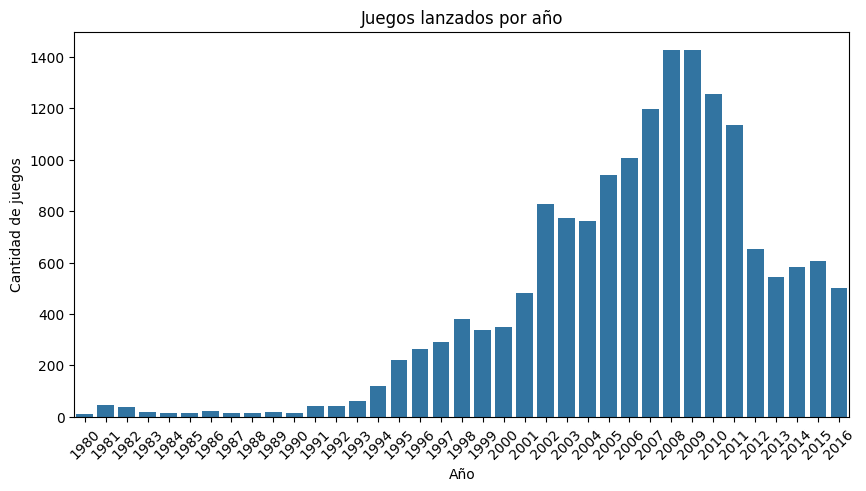

In [466]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=games_year,
    x='year_of_release',
    y='total_games'
)

plt.title("Juegos lanzados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)

plt.show()

- Los datos más significativos son de 2002 a 2011.

### Ventas por plataforma

In [467]:
# botener las plataformas con más ventas
top_10_platforms = (
    games_df.groupby('platform')['total_sales']
        .sum()
        .reset_index()
        .sort_values('total_sales', ascending=False)
).head(10)

print(top_10_platforms)

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12
15       PS       730.86
6       GBA       317.85
18      PS4       314.14
19      PSP       294.05
13       PC       259.52


In [468]:
# Obtener el nombre de las top 5 plataformas
top_10_platforms_name = []

for p in top_10_platforms['platform']:
    top_10_platforms_name.append(p)

print(top_10_platforms_name)

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4', 'PSP', 'PC']


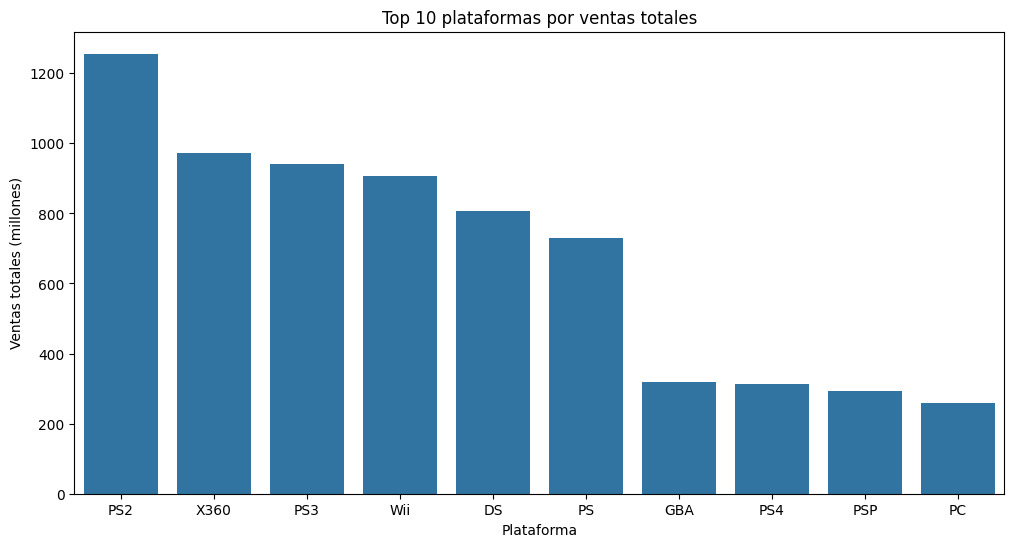

In [469]:
# Crea gráfico de barras para las top 10 plataformas
plt.figure(figsize=(12, 6))

sns.barplot(data=top_10_platforms, x='platform', y='total_sales')
plt.title('Top 10 plataformas por ventas totales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')

plt.show()

**¿Qué plataformas son líderes en ventas?**

- Las plataformas con más vendas:
    - PS2 con 1255.77 millones
    - X360 con 971.42 millones
    - PS3 con 939.65 millones

### Ciclo de vida de plataformas

In [470]:
# Seleccionar los datos para crear el ciclo de vida de las plataformas más populares
plat_lifecy_df = games_df[games_df['platform'].isin(top_10_platforms_name)]

print(plat_lifecy_df)

                                                   name platform  \
0                                            Wii Sports      Wii   
2                                        Mario Kart Wii      Wii   
3                                     Wii Sports Resort      Wii   
6                                 New Super Mario Bros.       DS   
7                                              Wii Play      Wii   
...                                                 ...      ...   
16708                Woody Woodpecker in Crazy Castle 5      GBA   
16709  SCORE International Baja 1000: The Official Game      PS2   
16710                     Samurai Warriors: Sanada Maru      PS3   
16711                                  LMA Manager 2007     X360   
16713                                  Spirits & Spells      GBA   

       year_of_release     genre  na_sales  eu_sales  jp_sales  other_sales  \
0                 2006    Sports     41.36     28.96      3.77         8.45   
2                 2008   

In [471]:
platform_sales_over_time = (
    plat_lifecy_df.groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
)

print(platform_sales_over_time)

    platform  year_of_release  total_sales
0         DS             1985         0.02
1         DS             2004        17.27
2         DS             2005       130.14
3         DS             2006       119.81
4         DS             2007       146.94
..       ...              ...          ...
112     X360             2012        99.74
113     X360             2013        88.58
114     X360             2014        34.74
115     X360             2015        11.96
116     X360             2016         1.52

[117 rows x 3 columns]


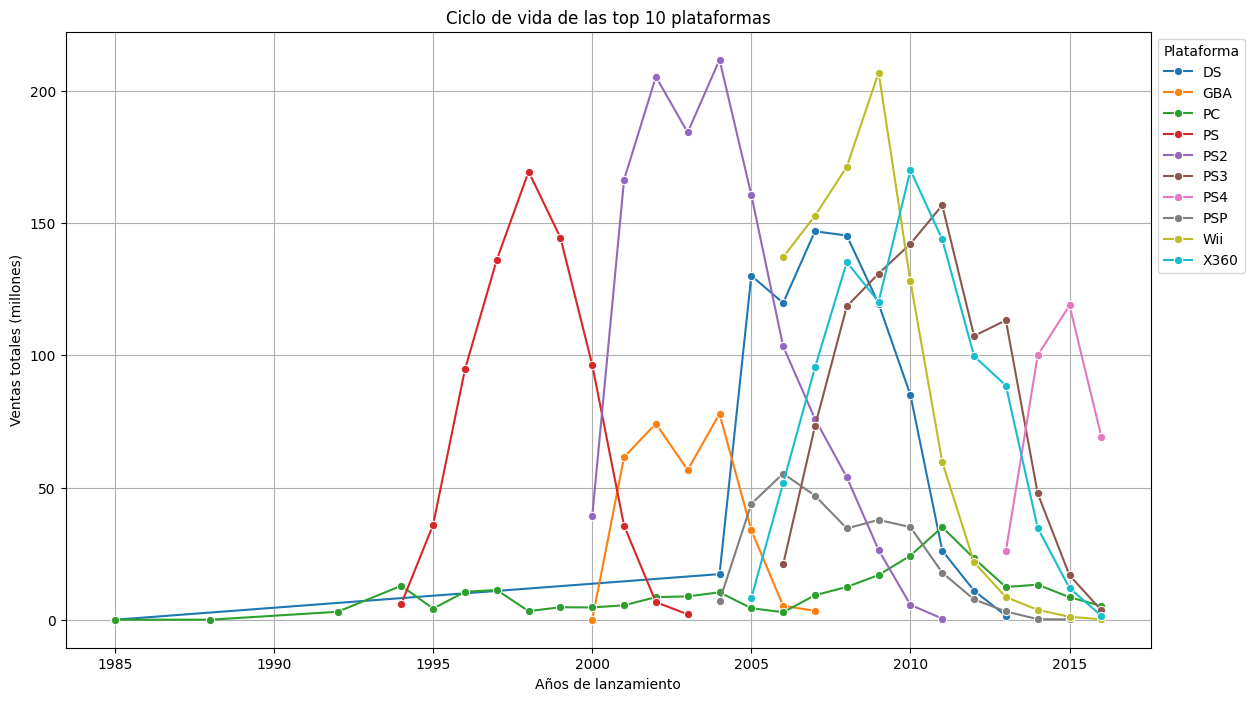

In [472]:
platform_sales_over_time = (
    plat_lifecy_df.groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=platform_sales_over_time,
    x='year_of_release',
    y='total_sales',
    hue='platform',
    marker='o'
)

plt.title('Ciclo de vida de las top 10 plataformas')
plt.xlabel('Años de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.legend(title='Plataforma', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.grid(True)
plt.show()

**¿Cuáles crecen y cuáles se reducen?**

Al gráficar el ciclo de vida de las plataformas podemos ver que:
- La única plataforma que se mantiene con ventas en el año 2016 es la plataforma PS4, tomando en cuenta solo las top 10 plataformas.
- Todas otras 9 plataformas, en el año 2016 sus ventas caen hasta cero o casi cero.

### ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?


In [473]:
games_top_platform = games_df[games_df['platform'].isin(top_10_platforms_name)]

print(games_top_platform)

                                                   name platform  \
0                                            Wii Sports      Wii   
2                                        Mario Kart Wii      Wii   
3                                     Wii Sports Resort      Wii   
6                                 New Super Mario Bros.       DS   
7                                              Wii Play      Wii   
...                                                 ...      ...   
16708                Woody Woodpecker in Crazy Castle 5      GBA   
16709  SCORE International Baja 1000: The Official Game      PS2   
16710                     Samurai Warriors: Sanada Maru      PS3   
16711                                  LMA Manager 2007     X360   
16713                                  Spirits & Spells      GBA   

       year_of_release     genre  na_sales  eu_sales  jp_sales  other_sales  \
0                 2006    Sports     41.36     28.96      3.77         8.45   
2                 2008   

In [474]:
max_sales_year = (
    games_top_platform.loc[games_top_platform.groupby('platform')['total_sales'].idxmax(),
                           ['platform', 'total_sales', 'year_of_release']]
    .rename(columns={
        'total_sales': 'max_sale',
        'year_of_release': 'max_sale_year'
    })
)

print(max_sales_year)

   platform  max_sale  max_sale_year
6        DS     29.80           2006
25      GBA     15.84           2002
85       PC      8.01           2009
52       PS     10.95           1997
17      PS2     20.81           2004
16      PS3     21.05           2013
31      PS4     14.63           2015
91      PSP      7.68           2005
0       Wii     82.54           2006
14     X360     21.82           2010


In [475]:
year_min_max = (
    games_top_platform.groupby('platform')
    .agg(
        start_date=('year_of_release', 'min'),
        end_date=('year_of_release', 'max')
    )
    .reset_index()
)

print(year_min_max)

  platform  start_date  end_date
0       DS        1985      2013
1      GBA        2000      2007
2       PC        1985      2016
3       PS        1994      2003
4      PS2        2000      2011
5      PS3        2006      2016
6      PS4        2013      2016
7      PSP        2004      2015
8      Wii        2006      2016
9     X360        2005      2016


In [476]:
platf_info = year_min_max.merge(max_sales_year, on='platform', how='left')

print(platf_info.head(10))

  platform  start_date  end_date  max_sale  max_sale_year
0       DS        1985      2013     29.80           2006
1      GBA        2000      2007     15.84           2002
2       PC        1985      2016      8.01           2009
3       PS        1994      2003     10.95           1997
4      PS2        2000      2011     20.81           2004
5      PS3        2006      2016     21.05           2013
6      PS4        2013      2016     14.63           2015
7      PSP        2004      2015      7.68           2005
8      Wii        2006      2016     82.54           2006
9     X360        2005      2016     21.82           2010


In [477]:
platf_info['start_to_max_sale'] = platf_info['max_sale_year'] - platf_info['start_date'] 
platf_info['max_sale_to_zero'] = platf_info['end_date'] - platf_info['max_sale_year'] 

print(platf_info.head(10))

  platform  start_date  end_date  max_sale  max_sale_year  start_to_max_sale  \
0       DS        1985      2013     29.80           2006                 21   
1      GBA        2000      2007     15.84           2002                  2   
2       PC        1985      2016      8.01           2009                 24   
3       PS        1994      2003     10.95           1997                  3   
4      PS2        2000      2011     20.81           2004                  4   
5      PS3        2006      2016     21.05           2013                  7   
6      PS4        2013      2016     14.63           2015                  2   
7      PSP        2004      2015      7.68           2005                  1   
8      Wii        2006      2016     82.54           2006                  0   
9     X360        2005      2016     21.82           2010                  5   

   max_sale_to_zero  
0                 7  
1                 5  
2                 7  
3                 6  
4        

In [478]:
# Constante para determinar el año apartir del cual se considera antiguo
ancient = 2005

def platform_type(year):
    if year > 2010:
        return 'new'
    else: 
        return 'ancient'

platf_info['type'] = platf_info['end_date'].apply(platform_type)

print(platf_info)

  platform  start_date  end_date  max_sale  max_sale_year  start_to_max_sale  \
0       DS        1985      2013     29.80           2006                 21   
1      GBA        2000      2007     15.84           2002                  2   
2       PC        1985      2016      8.01           2009                 24   
3       PS        1994      2003     10.95           1997                  3   
4      PS2        2000      2011     20.81           2004                  4   
5      PS3        2006      2016     21.05           2013                  7   
6      PS4        2013      2016     14.63           2015                  2   
7      PSP        2004      2015      7.68           2005                  1   
8      Wii        2006      2016     82.54           2006                  0   
9     X360        2005      2016     21.82           2010                  5   

   max_sale_to_zero     type  
0                 7      new  
1                 5  ancient  
2                 7      n

In [479]:
# Promedio en el que las plataformas nuevas aparecen

new_platform = platf_info.groupby('type')['start_to_max_sale'].mean().reset_index()
old_platform = platf_info.groupby('type')['max_sale_to_zero'].mean().reset_index()

new_plat = new_platform.loc[1, 'start_to_max_sale']
anc_plat = old_platform.loc[1, 'max_sale_to_zero']

print(f'La nuevas plataformas tardan un promedio de {new_plat} años en aparecer.')
print(f'Las antiguas plataformas tardan un promedio de {anc_plat} años en desaparecer.')

La nuevas plataformas tardan un promedio de 8.0 años en aparecer.
Las antiguas plataformas tardan un promedio de 6.375 años en desaparecer.


Observaciones:

- Las nuevas plataformas tardan un promedio de 8.0 años en aparecer.
- Las antiguas plataformas tardan un promedio de 6.3 años en aparecer.

Para las plataformas antiguas se tomo en cuenta aquellas plataformas que desaparecieron antes del 2005.

Para realizar este calculo se tomo el dataframe de las top 10 plataformas, se obtuvo la fecha de inicio o fin de la plataforma y se obtuvo también el año en el que alcanzaron el pico más alto en ventas, luego se resto la fecha de lanzamiento de la plataforma con la fecha de pico más alto en ventas y así sucesivamente con las plataformas antiguas, y finalmente obtuve la media de esos valores.

### Período relevante para el análisis

In [480]:
recent_period = games_df[games_df['year_of_release'].between(2014, 2016)]
active_platforms_recent = recent_period.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()

print('Top 10 plataformas más activas en 2014-2016')
print(active_platforms_recent.head(10))

print(f'\nJuegos lanzados en 2014-2016: {len(recent_period)}')
print(f'Porcentaje del total: {len(recent_period)/len(games_df)*100:.1f}%')

Top 10 plataformas más activas en 2014-2016
  platform  total_sales
0      PS4       288.15
1     XOne       140.36
2      3DS        86.68
3      PS3        68.18
4     X360        48.22
5     WiiU        42.98
6       PC        27.05
7      PSV        22.40
8      Wii         5.07
9      PSP         0.36

Juegos lanzados en 2014-2016: 1689
Porcentaje del total: 10.1%


### Ventas globales de todos los juegos

In [481]:
global_sales = (
    recent_period.groupby('platform')['total_sales']
    .sum()
    .reset_index()
    .sort_values('total_sales', ascending=False)
    )

print(global_sales.head(15))

  platform  total_sales
3      PS4       288.15
9     XOne       140.36
0      3DS        86.68
2      PS3        68.18
8     X360        48.22
7     WiiU        42.98
1       PC        27.05
5      PSV        22.40
6      Wii         5.07
4      PSP         0.36


In [482]:
# Filtrar las top 10 plataformas
top_10_platforms_filtered = recent_period[recent_period['platform'].isin(top_10_platforms_name)]

print(top_10_platforms_filtered.head(10))

                               name platform  year_of_release         genre  \
31        Call of Duty: Black Ops 3      PS4             2015       Shooter   
42               Grand Theft Auto V      PS4             2014        Action   
77                          FIFA 16      PS4             2015        Sports   
87     Star Wars Battlefront (2015)      PS4             2015       Shooter   
92   Call of Duty: Advanced Warfare      PS4             2014       Shooter   
94                          FIFA 17      PS4             2016        Sports   
105                       Fallout 4      PS4             2015  Role-Playing   
143                         FIFA 15      PS4             2014        Sports   
154                         Destiny      PS4             2014       Shooter   
171      Uncharted 4: A Thief's End      PS4             2016       Shooter   

     na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31       6.03      5.86      0.36         2.38        

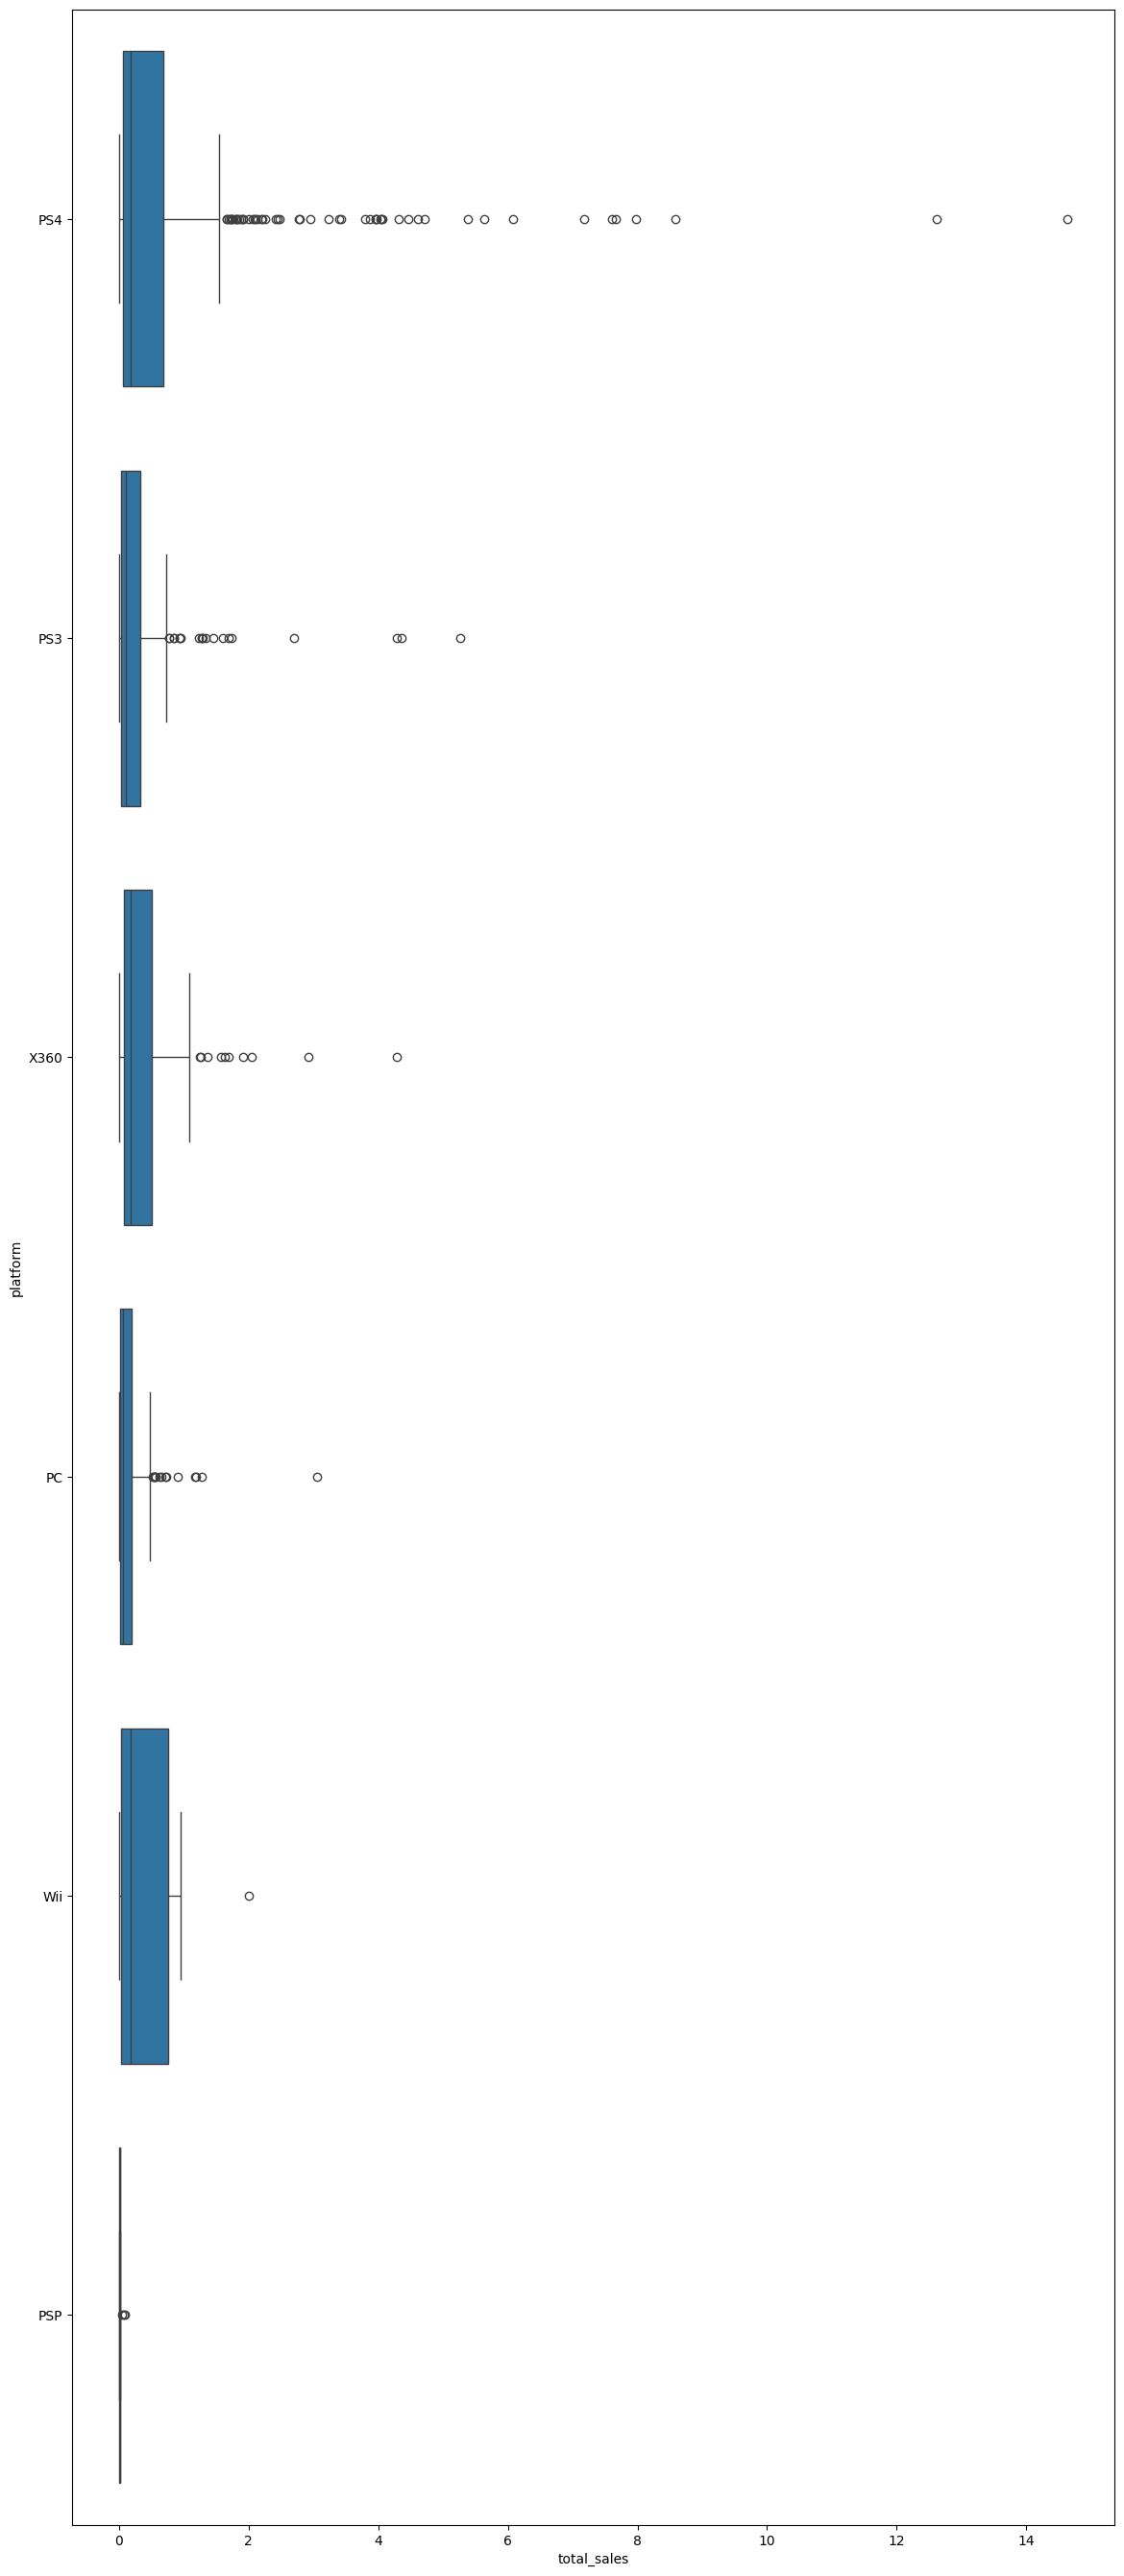

In [483]:
# Crear un boxplot de las ventas globales por plataforma
plt.figure(figsize=(14, 34))

sns.boxplot(
    data=top_10_platforms_filtered,
    x='total_sales',
    y='platform',
)

plt.show()

**¿Qué sucede con las ventas promedio en varias plataformas?**

- En el boxplot, la mayoría de plataformas muestran medianas bajas y cajas cerca de valores pequeños, lo que indica que la mayoría de juegos venden poco.
- Hay muchos valores atípicos (outliers) altos, así que unos pocos títulos exitosos concentran gran parte de las ventas.
- Las plataformas con mediana más alta tienen mejor rendimiento “típico” por juego (no solo casos excepcionales).
- Las plataformas con cajas/bigotes más amplios presentan mayor variabilidad: conviven juegos con ventas muy bajas y algunos muy altos.



### Correlación entre las reseñas y las ventas de las plataforma PS4

In [484]:
# Tipos
print(recent_period.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1689 entries, 31 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             1689 non-null   object 
 1   platform         1689 non-null   object 
 2   year_of_release  1689 non-null   Int64  
 3   genre            1689 non-null   object 
 4   na_sales         1689 non-null   float64
 5   eu_sales         1689 non-null   float64
 6   jp_sales         1689 non-null   float64
 7   other_sales      1689 non-null   float64
 8   critic_score     718 non-null    float64
 9   user_score       888 non-null    float64
 10  rating           1689 non-null   object 
 11  total_sales      1689 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 173.2+ KB
None


In [485]:
# Filtara los datos de PS4
ps4 = recent_period[recent_period['platform'] == 'PS4']

print(ps4.head())

                              name platform  year_of_release    genre  \
31       Call of Duty: Black Ops 3      PS4             2015  Shooter   
42              Grand Theft Auto V      PS4             2014   Action   
77                         FIFA 16      PS4             2015   Sports   
87    Star Wars Battlefront (2015)      PS4             2015  Shooter   
92  Call of Duty: Advanced Warfare      PS4             2014  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31      6.03      5.86      0.36         2.38           NaN         NaN   
42      3.96      6.31      0.38         1.97          97.0         8.3   
77      1.12      6.12      0.06         1.28          82.0         4.3   
87      2.99      3.49      0.22         1.28           NaN         NaN   
92      2.81      3.48      0.14         1.23          83.0         5.7   

     rating  total_sales  
31  unknown        14.63  
42        M        12.62  
77        E         8.58  
87

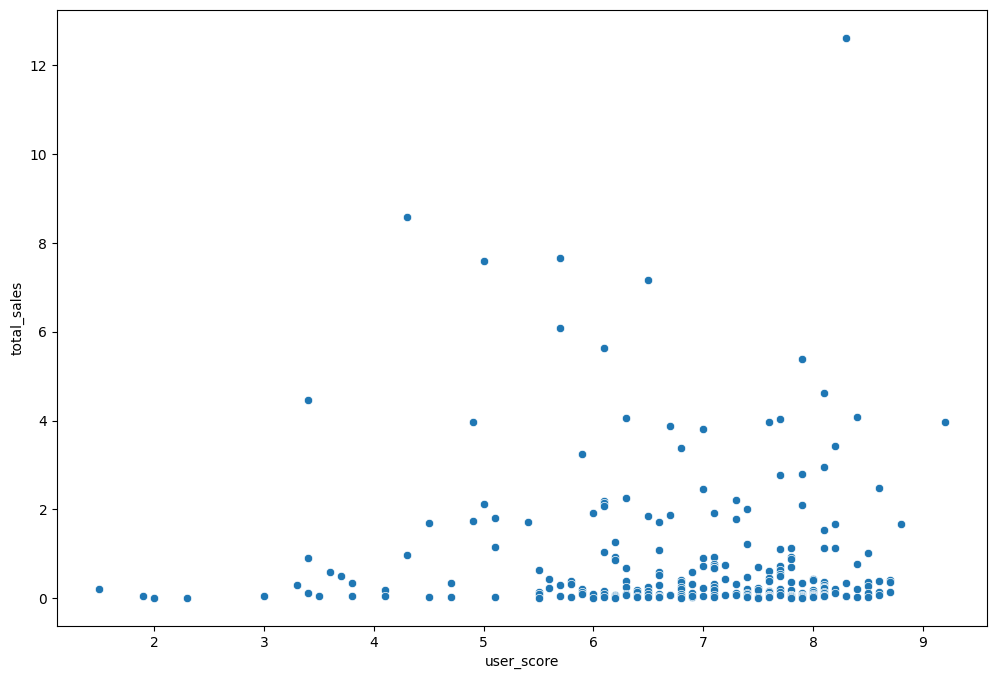

In [486]:
# Gráfico de dispersión para ver visualizar la correlación de la reseña de los usuarios y las ventas totales.
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=ps4,
    x='user_score',
    y='total_sales'
)

plt.show()

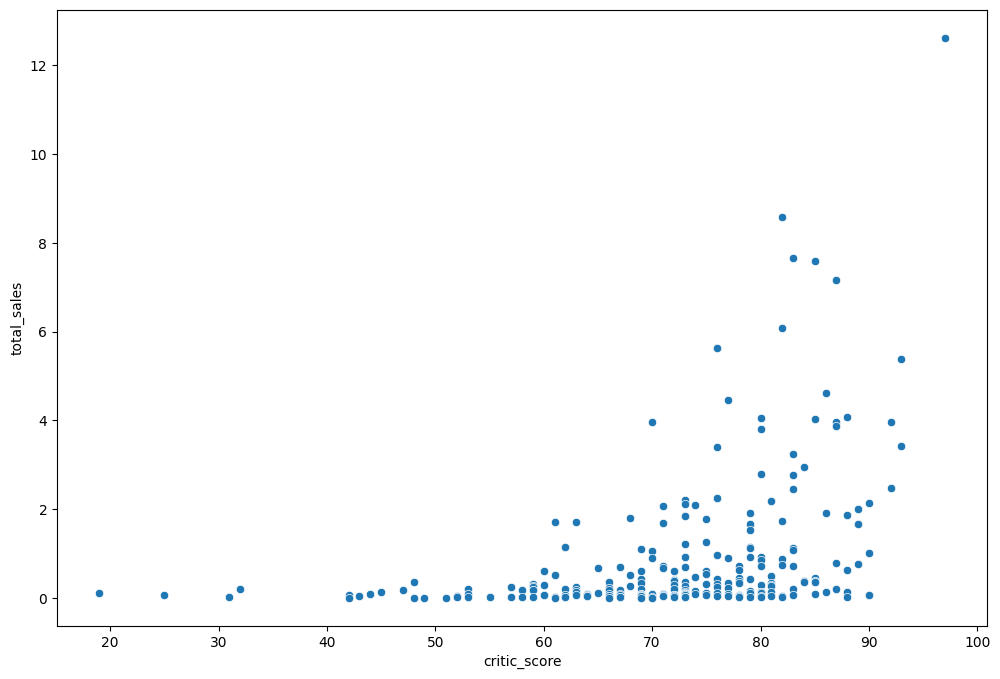

In [487]:
# Gráfico de dispersión para ver visualizar la correlación de la reseña de los criticos y las ventas totales.
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=ps4,
    x='critic_score',
    y='total_sales'
)

plt.show()

In [488]:
# Coeficiente de correlación entre las reseñas de los usuarios y las ventas totales
print('Coeficiente de correlación de las reseña de los usuarios con las ventas totales de la plataforma:')
print(ps4['user_score'].corr(ps4['total_sales']))
print('\nCoeficiente de correlación de las reseña de los criticos con las ventas totales de la plataforma:')
print(ps4['critic_score'].corr(ps4['total_sales']))


Coeficiente de correlación de las reseña de los usuarios con las ventas totales de la plataforma:
-0.04013158947269733

Coeficiente de correlación de las reseña de los criticos con las ventas totales de la plataforma:
0.4026614106810409


**Conclusión:**

- Puedo observar que con la puntaje de los criticos obtenemos una correlación mayor que con el puntaje de los usuarios.
- No podría decir que el puntaje del critico incrementa las ventas, pero si una mejor puntuación de los criticos reflejaria mejores ganancias.

### Comparación del mismo juego en diferentes plataformas

In [489]:
# Top 10 de los juegos con más ventas totales
top_10_games = ps4.sort_values(by='total_sales', ascending=False).head(10)

print(top_10_games)

                               name platform  year_of_release         genre  \
31        Call of Duty: Black Ops 3      PS4             2015       Shooter   
42               Grand Theft Auto V      PS4             2014        Action   
77                          FIFA 16      PS4             2015        Sports   
87     Star Wars Battlefront (2015)      PS4             2015       Shooter   
92   Call of Duty: Advanced Warfare      PS4             2014       Shooter   
94                          FIFA 17      PS4             2016        Sports   
105                       Fallout 4      PS4             2015  Role-Playing   
143                         FIFA 15      PS4             2014        Sports   
154                         Destiny      PS4             2014       Shooter   
171      Uncharted 4: A Thief's End      PS4             2016       Shooter   

     na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31       6.03      5.86      0.36         2.38        

In [490]:
# Obteniendo el nombre de los juegos en la plataforma seleccionada
ps4_game_names = top_10_games['name'].tolist()

print(f'Juegos totales: {len(ps4_game_names)} \n')
for name in ps4_game_names:
    print(name)

Juegos totales: 10 

Call of Duty: Black Ops 3
Grand Theft Auto V
FIFA 16
Star Wars Battlefront (2015)
Call of Duty: Advanced Warfare
FIFA 17
Fallout 4
FIFA 15
Destiny
Uncharted 4: A Thief's End


In [491]:
same_games_comparison = recent_period[recent_period['name'].isin(ps4_game_names)]

print(f'Juegos encontrados totales: {len(same_games_comparison)}')
print(same_games_comparison.head(25))

Juegos encontrados totales: 42
                               name platform  year_of_release         genre  \
31        Call of Duty: Black Ops 3      PS4             2015       Shooter   
42               Grand Theft Auto V      PS4             2014        Action   
77                          FIFA 16      PS4             2015        Sports   
87     Star Wars Battlefront (2015)      PS4             2015       Shooter   
92   Call of Duty: Advanced Warfare      PS4             2014       Shooter   
94                          FIFA 17      PS4             2016        Sports   
99        Call of Duty: Black Ops 3     XOne             2015       Shooter   
105                       Fallout 4      PS4             2015  Role-Playing   
143                         FIFA 15      PS4             2014        Sports   
154                         Destiny      PS4             2014       Shooter   
165              Grand Theft Auto V     XOne             2014        Action   
171      Uncharted 4:

In [492]:
same_games_comparison = (
    same_games_comparison.groupby(['name', 'platform'])['total_sales']
    .sum()
    .reset_index()
    .sort_values(by=['name', 'total_sales'], ascending=[True, True])
    )

print(same_games_comparison.head(25))

                              name platform  total_sales
0   Call of Duty: Advanced Warfare       PC         0.41
3   Call of Duty: Advanced Warfare     X360         4.28
1   Call of Duty: Advanced Warfare      PS3         4.36
4   Call of Duty: Advanced Warfare     XOne         5.26
2   Call of Duty: Advanced Warfare      PS4         7.66
5        Call of Duty: Black Ops 3       PC         0.26
6        Call of Duty: Black Ops 3      PS3         1.69
8        Call of Duty: Black Ops 3     X360         1.70
9        Call of Duty: Black Ops 3     XOne         7.39
7        Call of Duty: Black Ops 3      PS4        14.63
10                         Destiny      PS3         1.61
12                         Destiny     X360         1.92
13                         Destiny     XOne         3.37
11                         Destiny      PS4         5.64
15                         FIFA 15       PC         0.29
14                         FIFA 15      3DS         0.46
19                         FIFA

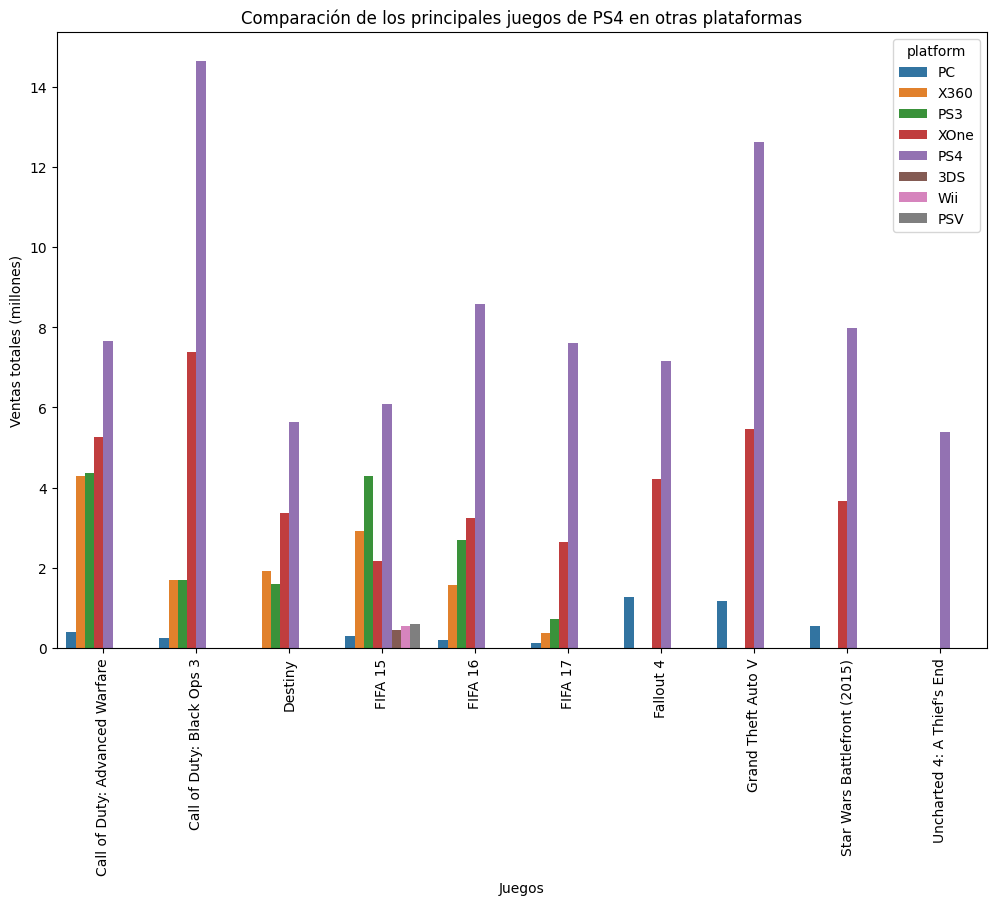

In [493]:
# Gráfica para compara los diferentes juegos con éxitos en otraso plataformas
plt.figure(figsize=(12, 8))

sns.barplot(
    data=same_games_comparison,
    x='name',
    y='total_sales',
    hue='platform'
)
plt.xticks(rotation=90)
plt.title('Comparación de los principales juegos de PS4 en otras plataformas')
plt.xlabel('Juegos')
plt.ylabel('Ventas totales (millones)')

plt.show()

Al comparar los 10 juegos con mayores ventas en PS4 frente a otras plataformas, se observa que el éxito no se distribuye de manera uniforme. Algunos títulos conservan ventas altas en varias plataformas, mientras que otros dependen más del ecosistema de PS4. Esto indica que la plataforma influye de forma importante en el rendimiento comercial de un juego, incluso cuando se trata del mismo título.

### Distribución de los juegos por género

In [494]:
genre_counts = recent_period['genre'].value_counts()

print(f'Cantidad de juegos pos género: {genre_counts}')

Cantidad de juegos pos género: genre
Action          619
Role-Playing    221
Adventure       185
Sports          161
Shooter         128
Misc            113
Racing           69
Fighting         60
Simulation       44
Platform         38
Strategy         37
Puzzle           14
Name: count, dtype: int64


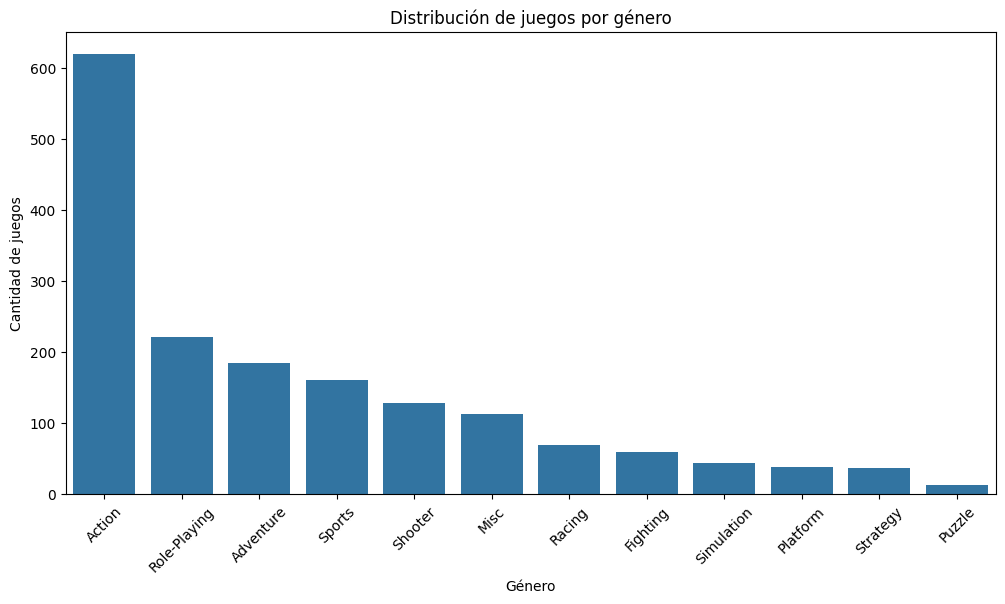

In [495]:
plt.figure(figsize=(12, 6))

sns.barplot(data=genre_counts)
plt.title('Distribución de juegos por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45)

plt.show()

In [496]:
# Ventas totales por género
genre_sales = recent_period.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count'])
genre_sales.columns = ['total_sales', 'mean_sales', 'game_amount']
genre_sales = genre_sales.sort_values('total_sales', ascending=False)

print(genre_sales)

              total_sales  mean_sales  game_amount
genre                                             
Action             199.36    0.322068          619
Shooter            170.94    1.335469          128
Sports             109.48    0.680000          161
Role-Playing       101.44    0.459005          221
Misc                37.55    0.332301          113
Fighting            28.22    0.470333           60
Racing              27.52    0.398841           69
Platform            18.09    0.476053           38
Adventure           17.55    0.094865          185
Simulation          13.13    0.298409           44
Strategy             3.96    0.107027           37
Puzzle               2.21    0.157857           14


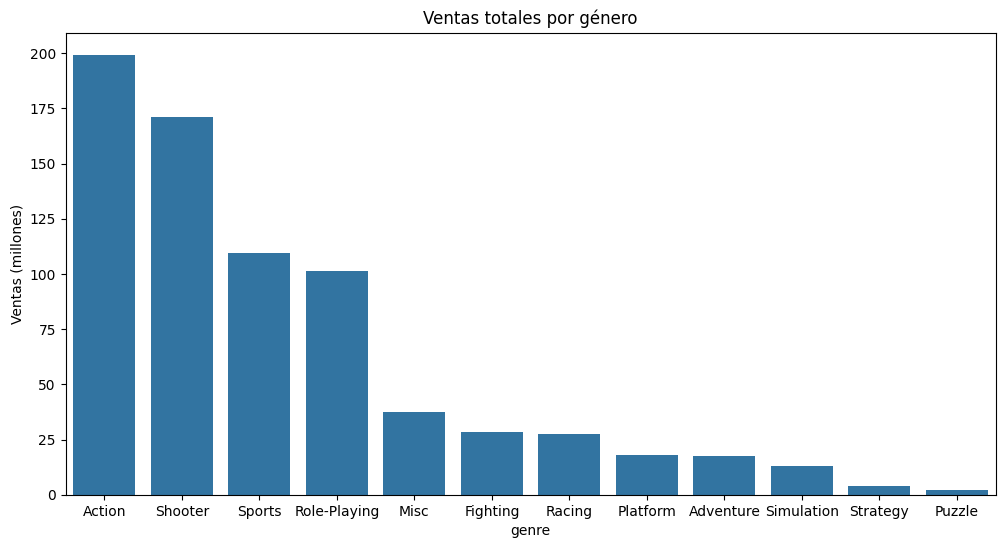

In [497]:
# Gráfico de ventas totales por género
plt.figure(figsize=(12, 6))

sns.barplot(data=genre_sales['total_sales'])
plt.title('Ventas totales por género')
plt.ylabel('Ventas (millones)')

plt.show()

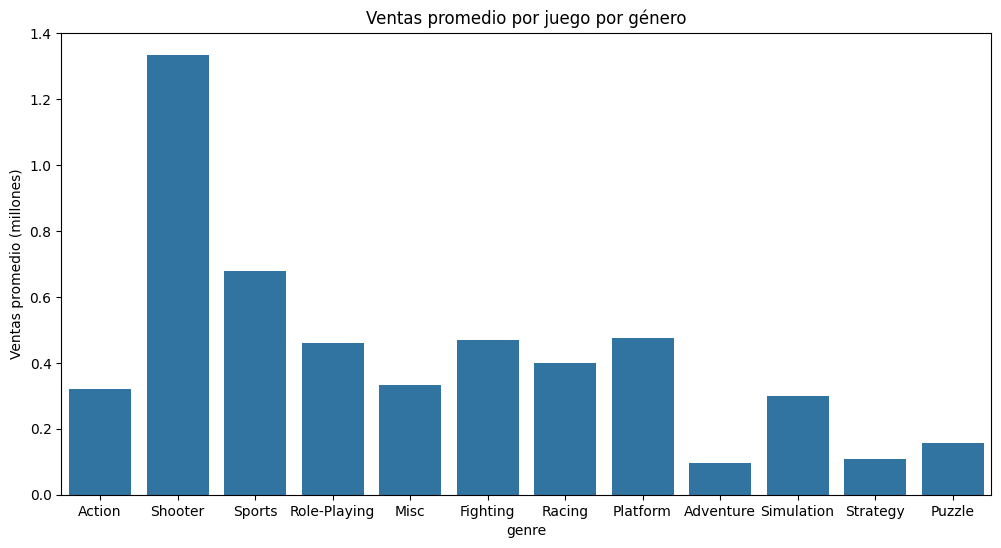

In [498]:
# Gráfico de ventas promedio por género
plt.figure(figsize=(12, 6))

sns.barplot(genre_sales['mean_sales'])
plt.title('Ventas promedio por juego por género')
plt.ylabel('Ventas promedio (millones)')

plt.show()


**¿Qué se puede decir de los géneros más rentables?**

Los géneros más rentables en ventas totales son Action y Shooter, seguidos por Sports y Role-Playing. Sin embargo, al mirar ventas promedio por juego, Shooter destaca claramente como el género con mejor rendimiento por título, mientras que Action vende mucho en total por su gran volumne de juegos.

**¿Puedes generalizar acerca de los géneros con ventas altas y bajas?**

En general, los géneros con ventas altas son los de mayor demanda masiva (Action, Shooter, Sports, Role-Playing), ya sea por volumne de lanzamiento o por alto rendimiento promedio. Los géneros con ventas bajas son Strategy y Puzzle (y también Adventure en promedio), lo que muestra menor atracción comercial en el período analizado.

## Paso 4. Crea un perfil de usuario para cada región

#### Variaciones en la cuota de mercado de una región a otra.

In [499]:
# Agrupar ventas por plataforma
na_sales_by_platform = (
    recent_period.groupby('platform')['na_sales']
    .sum()
    .reset_index()
)

# Calcular couta de mercado sobre el total regional
total_na_sales = na_sales_by_platform['na_sales'].sum()

na_sales_by_platform['market_share'] = (
    na_sales_by_platform['na_sales'] / total_na_sales * 100
)

# Ordenar y ver top 5
na_market_share_top5 = na_sales_by_platform.sort_values(
    'market_share', ascending=False
).head(5)

print(na_market_share_top5)

  platform  na_sales  market_share
3      PS4     98.61     34.714497
9     XOne     81.27     28.610153
8     X360     28.30      9.962684
0      3DS     22.64      7.970147
2      PS3     22.05      7.762445


In [500]:
na_market_share_top5.style.format({
    'na_sales': '{:.2f}',
    'market_share': '{:.2f}%'
})


,platform,na_sales,market_share
3,PS4,98.61,34.71%
9,XOne,81.27,28.61%
8,X360,28.30,9.96%
0,3DS,22.64,7.97%
2,PS3,22.05,7.76%


In [501]:
# Agrupar las ventas de europa por plataforma
eu_sales_by_platform = (
    recent_period.groupby('platform')['eu_sales']
    .sum()
    .reset_index()
)

# Calcular la couta de mercado sobre el total regional
total_eu_sales = eu_sales_by_platform['eu_sales'].sum()

eu_sales_by_platform['market_share'] = (
    eu_sales_by_platform['eu_sales'] / total_eu_sales * 100
)

# Ordenar y obtener el top 5
eu_market_share_top5 = eu_sales_by_platform.sort_values(
    'market_share', ascending=False
).head(5)

print(eu_market_share_top5)

  platform  eu_sales  market_share
3      PS4    130.04     48.041968
9     XOne     46.25     17.086597
2      PS3     25.54      9.435496
1       PC     17.97      6.638836
0      3DS     16.12      5.955372


In [502]:
# Estilos
eu_market_share_top5.style.format({
    'market_share': '{:.2f}%'
})

,platform,eu_sales,market_share
3,PS4,130.040000,48.04%
9,XOne,46.250000,17.09%
2,PS3,25.540000,9.44%
1,PC,17.970000,6.64%
0,3DS,16.120000,5.96%


In [503]:
# Agrupar ventas de japon por plataforma
jp_sales_by_platform = (
    recent_period.groupby('platform')['jp_sales']
    .sum()
    .reset_index()
)

# Calcular couta de mercado sobre el total regional
total_jp_sales = jp_sales_by_platform['jp_sales'].sum()
print(f'Ventas totales de la región: {total_jp_sales}\n')

jp_sales_by_platform['market_share'] = (
    jp_sales_by_platform['jp_sales'] / total_jp_sales * 100
)

# Ordenar y ver el top 5
jp_market_share_top5 = jp_sales_by_platform.sort_values(
    'market_share', ascending=False
).head()

print(jp_market_share_top5)

Ventas totales de la región: 93.08999999999999

  platform  jp_sales  market_share
0      3DS     44.24     47.523902
3      PS4     15.02     16.134923
5      PSV     14.54     15.619293
2      PS3     11.22     12.052852
7     WiiU      7.31      7.852616


In [504]:
# Estilos
jp_market_share_top5.style.format({
    'market_share': '{:.2f}%'
})

,platform,jp_sales,market_share
0,3DS,44.240000,47.52%
3,PS4,15.020000,16.13%
5,PSV,14.540000,15.62%
2,PS3,11.220000,12.05%
7,WiiU,7.310000,7.85%


**Observaciones:**

- PS4 domina en norteamerica con (34.71%) del mercado, de la misma forma en europa con (48.04%) y en japon en segundo lugar con (16.13%) del mercado.
- En japon prefieren 3DS con (47.52%) del mercado, mientras que en norteamerica solo el (7.97%) del mercado prefiere esta plataforma, similar a europa con (5.96%
).


#### 5 Géneros principales de cada región

In [505]:
# Géneros más populares de norteamerica
na_genres = (
    recent_period.groupby('genre')['na_sales']
    .sum()
    .reset_index()
    .sort_values('na_sales', ascending=False)
    .head(5)
)

print(na_genres)

           genre  na_sales
8        Shooter     79.02
0         Action     72.53
10        Sports     46.13
7   Role-Playing     33.47
3           Misc     15.05


In [506]:
# Géneros más populares en europa
eu_sales = (
    recent_period.groupby('genre')['eu_sales']
    .sum()
    .reset_index()
    .sort_values('eu_sales', ascending=False)
    .head()
)

print(eu_sales)

           genre  eu_sales
0         Action     74.68
8        Shooter     65.52
10        Sports     45.73
7   Role-Playing     28.17
6         Racing     14.13


In [507]:
# Géneros más populares en japon
jp_genres = (
    recent_period.groupby('genre')['jp_sales']
    .sum()
    .reset_index()
    .sort_values('jp_sales', ascending=False)
    .head()
)

print(jp_genres)

          genre  jp_sales
7  Role-Playing     31.16
0        Action     29.58
2      Fighting      6.37
3          Misc      5.61
8       Shooter      4.87


**Diferencia de una región a otra:**

- El género con más ventas en norteamerica es Shooter.
- El género con más ventas en europa es Action.
- El género con más ventas en japon es Role-Playing.
- El género Action encabeza las listas de los géneros con más ventas.

#### Impacto de la clasificación ESRB en las ventas de las regiones individuales

In [508]:
# Analizar si las clasificaciones afectan las ventas por región

esrb_impact = recent_period.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

print(esrb_impact)

         na_sales  eu_sales  jp_sales
rating                               
E           50.74     58.06      8.94
E10+        33.23     26.16      4.46
M           96.42     93.44      8.01
T           38.95     34.07     14.78
unknown     64.72     58.95     56.90


Veo que las clasificación ESBR si tiene un gran impacto en las ventas de las diferentes regiones.

El impacto de la clasificación ESBR tiene el mismo comportamiento tanto en norteamerica como en europa pero difiere con japon.

Juegos con clasificación para adultos venden más en norteamerica como en europa, en cambio en japon los juegos con más ventas son aquellos con clasificación para adolecentes.

**Un perfil de usuario:**

Los usuarios en norteamerica prefieren las plataformas PS4 y Xbox One, con los géneros Shooter y Action, y juegos con clasificación M y E.

## Paso 5. Probar las hipótesis

### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [509]:
# Obtener el grupo de Xbox One
xbox_one = recent_period[recent_period['platform'] == 'XOne']['user_score']
xbox_one = xbox_one.dropna()
print(f'Xbox One total de datos: {xbox_one.size}')

pc = recent_period[recent_period['platform'] == 'PC']['user_score']
pc = pc.dropna()
print(f'PC total de datos: {pc.size}')

Xbox One total de datos: 165
PC total de datos: 122


In [510]:
# prueba de hipótesis

alpha = 0.05

results = st.ttest_ind(xbox_one, pc)

print(f'valor p: {results.pvalue:.10f}')

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

valor p: 0.1045050792
No podemos rechazar la hipótesis nula


In [511]:
print(f'Media de las calificaciones del grupo Xbox One: {xbox_one.mean():.2f}')
print(f'Media de las calificaciones del grupo PC: {pc.mean():.2f}')

Media de las calificaciones del grupo Xbox One: 6.59
Media de las calificaciones del grupo PC: 6.30


**Resultados de la Prueba Estadística:**

**Hipótesis planteadas:**

- $H_0$ Las calificaciones promedio de los usuarios para la plataformas Xbox One y PC son las mismas. Devido a que la hipótesis nula representa que no hay efecto o diferencia.
- $H_1$ Las calificaciones promedio de los usuarios para la plataforma Xbox One son diferente a la de la PC. Y la hipótesis alternativa es lo opuesto a la nula.

**Metodología aplicada:**

Prueba t de Student para muestras independientes con varianzas iguales.

**Justificación del método:** 

Se tomo esta desición por que se sabe que la varianza son iguales, ya que ambos grupos provienen de un determinado rango de valores (calificaciones de 0 a 10).

**Resultados obtenidos:**

- Valor p = 0.1045050792
- Nivel de significancia α = 0.05

**Decisión estadística:** 

Como p-value > α, no podemos rechazar la hipótesis nula.

**Conclusión:**

Aunque Xbox One y PC no muestran diferencias estadísticamente significativas (p=0.10), Xbox One presenta una calificación promedio ligeramente superior (6.59 vs 6.30), sugiriendo una leve preferencia de usuarios.

### Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes

In [512]:
# Obtener ambos grupos
action = recent_period[recent_period['genre'] == 'Action']['user_score']
action = action.dropna()
print(f'Total de datos para el grupo del género Action: {action.size}')

sports = recent_period[recent_period['genre'] == 'Sports']['user_score']
sports = sports.dropna()
print(f'Total de datos para el grupo del género Sports: {sports.size}')

Total de datos para el grupo del género Action: 297
Total de datos para el grupo del género Sports: 127


In [513]:
# prueba de hipótesis

alpha = 0.05

results = st.ttest_ind(action, sports)

print(f'valor p:', results.pvalue)
print(f'valor p: {results.pvalue:.10f}')

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No debemos rechazar la hipótesis nula')

valor p: 2.871114798510586e-19
valor p: 0.0000000000
Rechazamos la hipótesis nula


In [514]:
print(f'Media de las calificaciones del género Action {action.mean()}')
print(f'Media de las calificaciones del género Sports {sports.mean()}')

Media de las calificaciones del género Action 6.760606060606061
Media de las calificaciones del género Sports 5.2251968503937


**Resultados de la Prueba Estadística:**

**Hipótesis planteadas:**

- $H_0$ Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales. 
- $H_1$ Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes. 

**Justificación de las hipótesis planteadas:**
- H0, Devido a que la hipótesis nula representa que no hay efecto o diferencia.
- H1, Devido a que la hipótesis alternativa es lo opuesto a la nula.

**Metodología aplicada:** 
Prueba t de Student para muestras independientes con varianzas iguales.

**Justificación del método:**

Se tomo esta desición por que se sabe que la varianza son iguales, ya que ambos grupos provienen de un determinado rango de valores (calificaciones).

**Resultados obtenidos:**
- Valor p = 2.871114798510586e-19
- Nivel de significancia α = 0.05

**Decisión estadística:** 

Como p-value < α, se puede rechazar H0.

**Conclusión:** 

Los géneros Action y Sports sí presentan diferencias significativas (p<0.05), con Action obteniendo calificaciones superiores (6.76 vs 5.23), por lo que se recomienda priorizar Action sobre Sports.

## Paso 6. Conclusión general

**Objetivo del proyecto:** Identificar patrones que determinen si un juego tiene éxito o no.

**Basándome en el análisis completo de los datos de videojuegos, puedo extraer las siguientes conclusiones clave:**

Tendencias del mercado de videojuegos

- Las plataformas tiene un ciclo típico de alrededor de 8 años para emerger y 6 años para declinar.
- Para 2017, las plataformas más prometedoras son Playstation 4 y Xbox One.
- Los datos muestran que el período 2014-2016 es el más relevante para predecir tendencias de 2017.

Diferencias regionales significativas

- En norteamerica prefieren géneros como Shooter, Action y Sports, y las plataformas PS4, Xbox One y Xbox 360.
- En europa prefieren géneros como Action, Shooter y Sports, y las plataformas PS4, Xbox One y PS3.
- En japon prefieren géneros como Role-Playing, Action y Fighting, y las plataformas 3DS, PS4 y PSV.

Factores de éxito

- Si el juego tiene una clasificación M (para adultos).
- Los géneros que identifique más rentables son Action y Shooter.


**Recomendaciones para Ice**

Para la campaña de 2017, recomiendo:
1. Enfocar inversión en las plataformas PS4 y Xbox One, que dominan el mercado en 2014-2016 con 34.7% y 28.6% respectivamente en Norteamérica.
2. Priorizar el género Action como primera opción (calificación promedio 6.76). Considerar Sports como opción secundaria debido a su menor calificación (5.23), pero mantenerlo por su popularidad regional.
3. Considerar las clasificaciones M, T y E del ESRB para los juegos.
4. Las pruebas de hipótesis revelan que Xbox One tiene una ligera ventaja en calificaciones sobre PC (6.59 vs 6.30), aunque no estadísticamente significativa. Para Action vs Sports, sí existe diferencia significativa (p<0.05), confirmando que Action debe ser la prioridad principal.

Esta estrategia se basa en datos del período 2014-2016, el más relevante para predecir el éxito en 2017.